In [1]:
from pyscf import gto, scf
import numpy as np

# ──────────────────────────────────────────────────────────────
# 1. Define the LiPF6 molecule (neutral Li+ · PF6– pair)
#    - P–F bond length ≈ 1.57 Å (ideal octahedron)
#    - Li+ placed 3 Å from P along +x for simplicity
# ──────────────────────────────────────────────────────────────
mol = gto.Mole()
mol.atom = '''
P        -0.000000        0.000000        0.207689
F         0.000000        1.159716       -1.114057
F        -0.000000       -1.187351        1.269191
F        -1.609678        0.000000        0.083000
F         1.609678       -0.000000        0.083000
F        -0.000000       -1.159716       -1.114057
F         0.000000        1.187351        1.269191
Li        0.000000        0.000000       -2.467253
'''
mol.basis  = 'cc-pVDZ' #'631g*'         # minimal basis for quick tests
mol.charge = 0                # Li+ + PF6– → neutral overall
mol.spin   = 0                # closed‑shell RHF
mol.build()

# ──────────────────────────────────────────────────────────────
# 2. Hartree–Fock calculation
# ──────────────────────────────────────────────────────────────
mf = scf.RHF(mol)
mf.kernel()

# ──────────────────────────────────────────────────────────────
# 3. Orbital energies and occupation analysis
# ──────────────────────────────────────────────────────────────
mo_energies  = mf.mo_energy
n_electrons  = mol.nelectron

print("\n📊  Orbital Energies (LiPF₆):")
for i, e in enumerate(mo_energies):
    occ = "occupied" if i < n_electrons // 2 else "virtual"
    print(f"  Orbital {i:2d} : {e: .6f} Ha   →  {occ}")

# ──────────────────────────────────────────────────────────────
# 4. Simple active‑space suggestions
#    • Freeze very low‑lying core orbitals (e < −0.8 Ha)
#    • Remove high virtuals            (e >  +0.5 Ha)
#    Adjust thresholds to taste!
# ──────────────────────────────────────────────────────────────
core_threshold    = -0.8
virtual_threshold =  0.5

frozen  = [i for i, e in enumerate(mo_energies) if e < core_threshold]
removed = [i for i, e in enumerate(mo_energies) if e > virtual_threshold]

print("\nSuggested core orbitals to freeze :", frozen)
print("Suggested high virtuals to remove :", removed)
print("Active orbitals (keep the rest!)")


converged SCF energy = -945.081392208817

📊  Orbital Energies (LiPF₆):
  Orbital  0 : -80.275622 Ha   →  occupied
  Orbital  1 : -26.321234 Ha   →  occupied
  Orbital  2 : -26.321222 Ha   →  occupied
  Orbital  3 : -26.305222 Ha   →  occupied
  Orbital  4 : -26.305221 Ha   →  occupied
  Orbital  5 : -26.304625 Ha   →  occupied
  Orbital  6 : -26.304614 Ha   →  occupied
  Orbital  7 : -7.766809 Ha   →  occupied
  Orbital  8 : -5.667646 Ha   →  occupied
  Orbital  9 : -5.667318 Ha   →  occupied
  Orbital 10 : -5.667068 Ha   →  occupied
  Orbital 11 : -2.519317 Ha   →  occupied
  Orbital 12 : -1.689192 Ha   →  occupied
  Orbital 13 : -1.615776 Ha   →  occupied
  Orbital 14 : -1.612101 Ha   →  occupied
  Orbital 15 : -1.611174 Ha   →  occupied
  Orbital 16 : -1.584062 Ha   →  occupied
  Orbital 17 : -1.577856 Ha   →  occupied
  Orbital 18 : -0.932687 Ha   →  occupied
  Orbital 19 : -0.803652 Ha   →  occupied
  Orbital 20 : -0.801482 Ha   →  occupied
  Orbital 21 : -0.794544 Ha   →  occupie

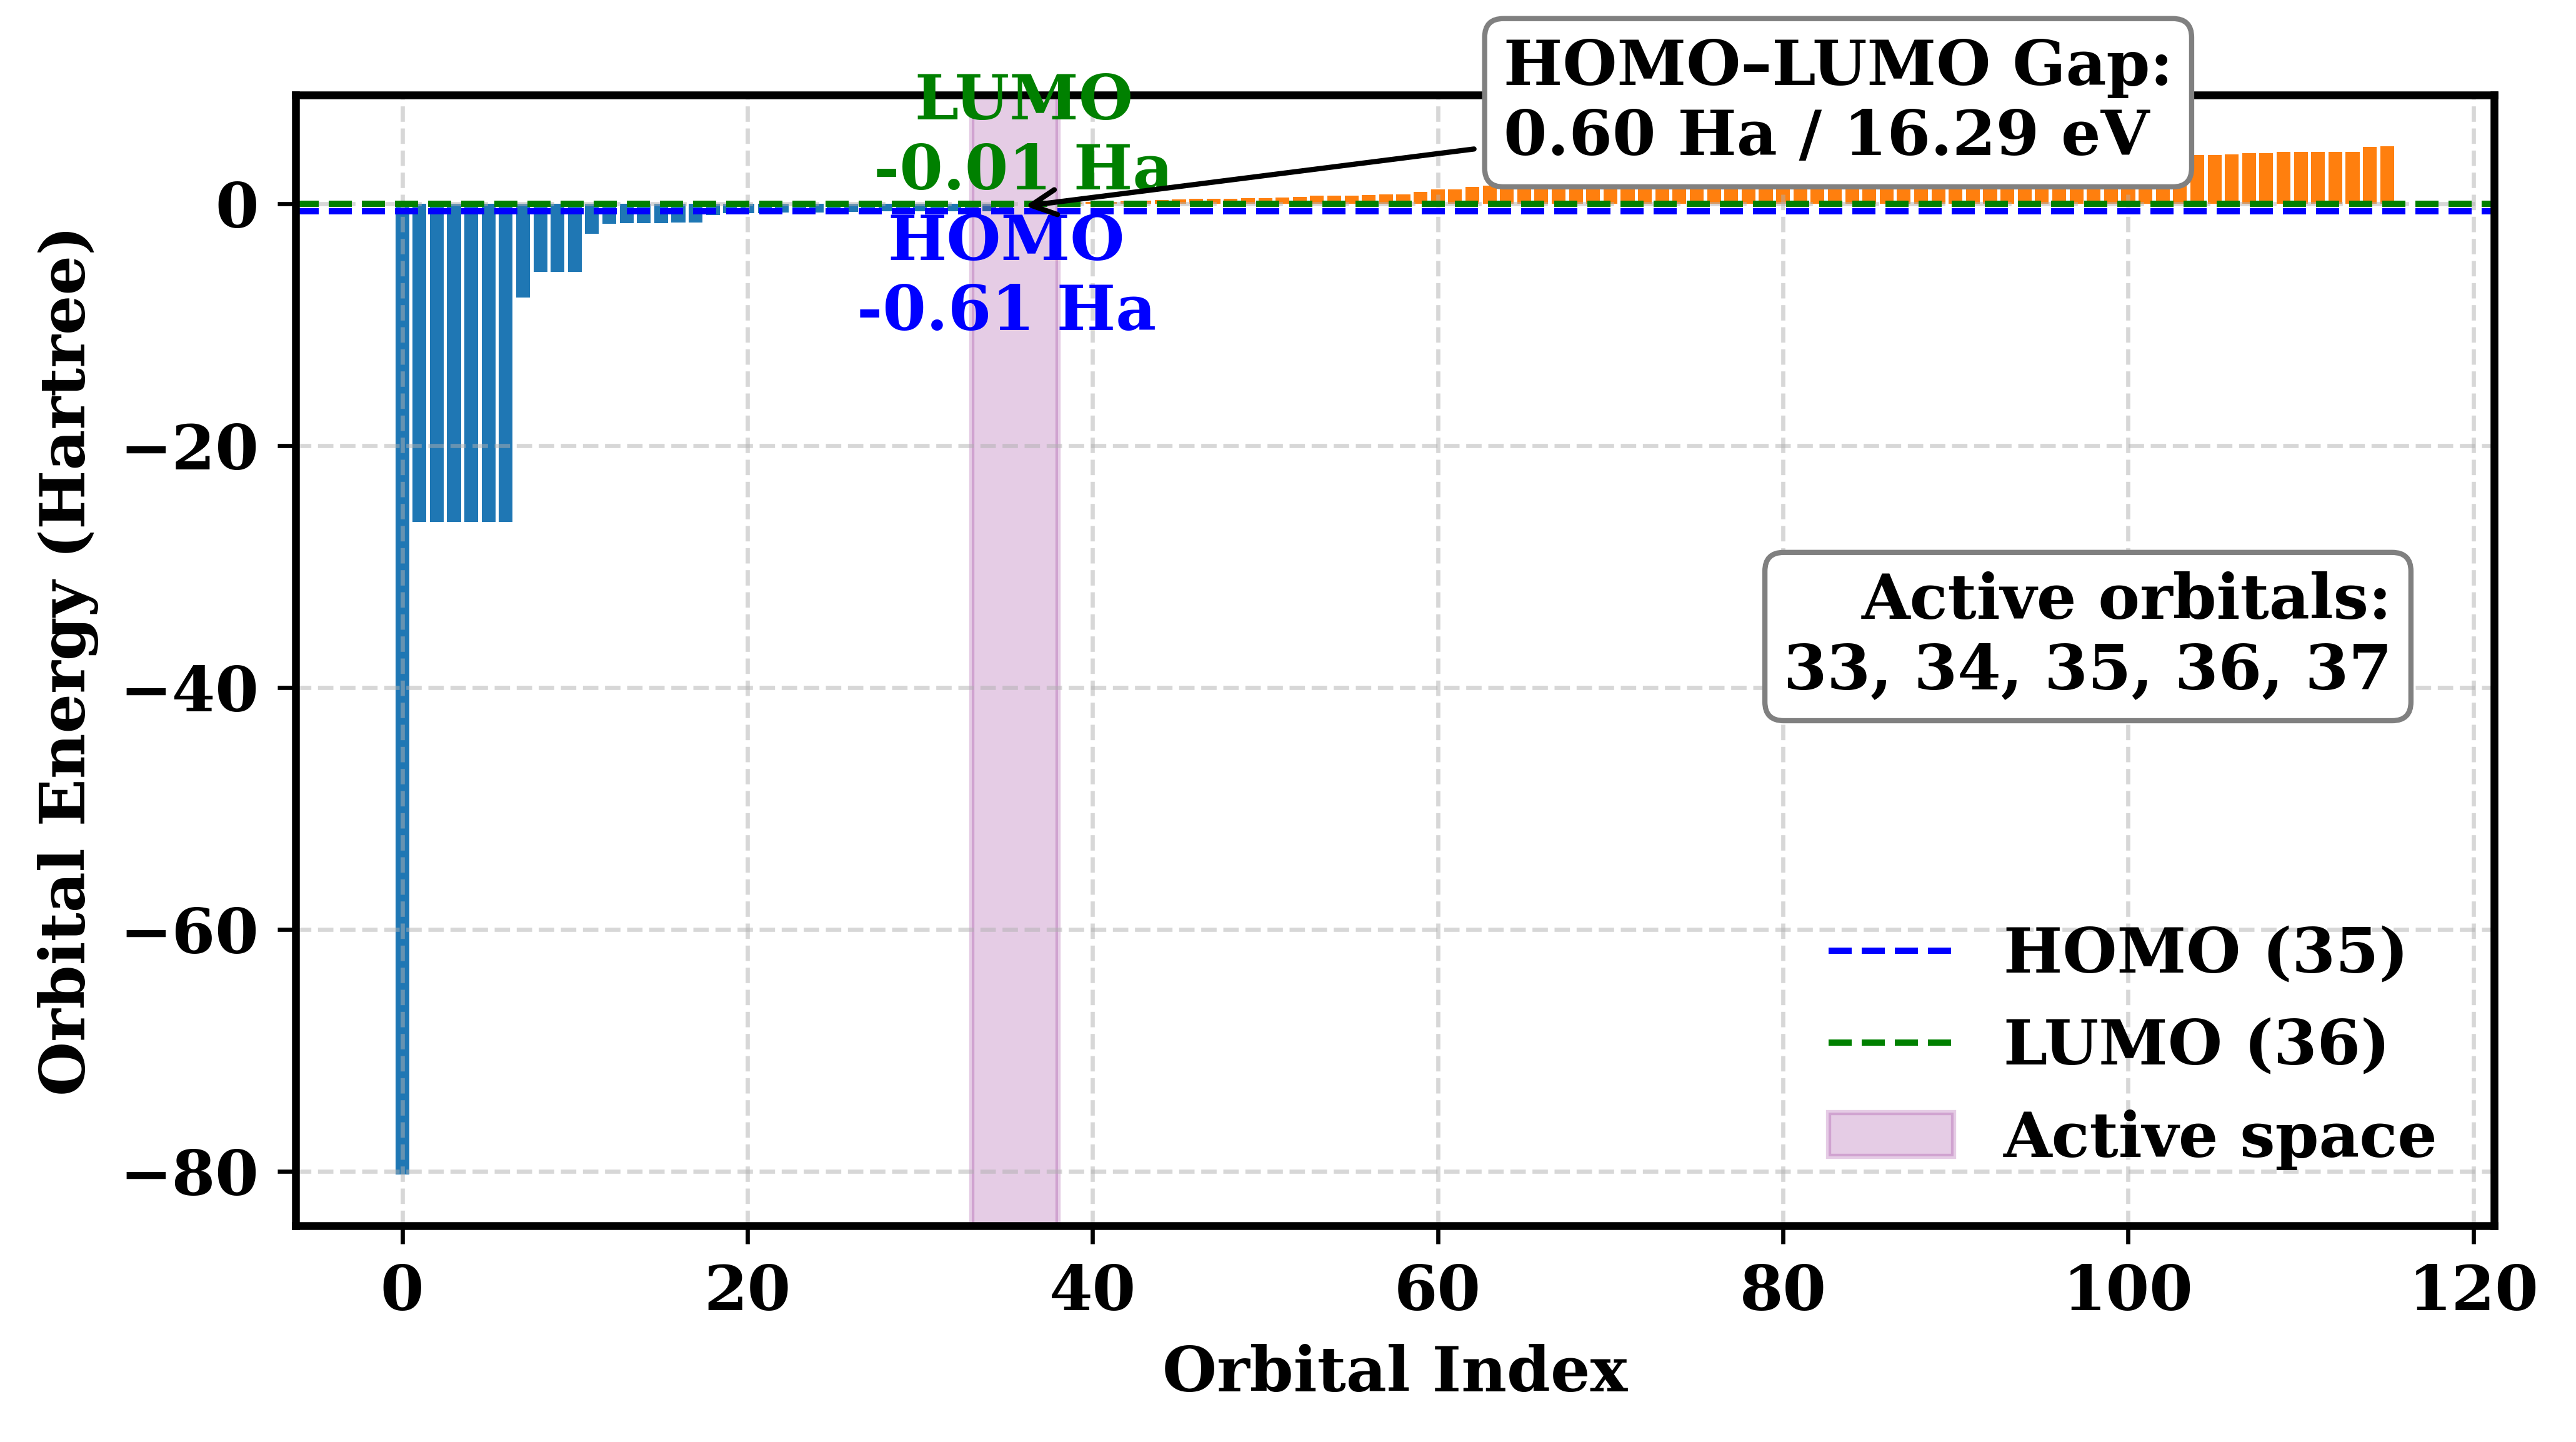

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import matplotlib as mpl

# ───────────────────────────────────────────────
# Global styling: Times New Roman, 600 DPI
# ───────────────────────────────────────────────
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 600,
    'savefig.dpi': 600
})

# ───────────────────────────────────────────────
# Inputs from PySCF or dummy data for testing
# ───────────────────────────────────────────────
# Replace with:
mo_energies = mf.mo_energy
n_electrons = mol.nelectron

#mo_energies = np.sort(np.random.uniform(-1.5, 1.5, 80))  # Placeholder energies
#n_electrons = 78  # Closed-shell system with 39 occupied orbitals

# ───────────────────────────────────────────────
# HOMO & LUMO detection
# ───────────────────────────────────────────────
homo = n_electrons // 2 - 1
lumo = homo + 1
homo_energy = mo_energies[homo]
lumo_energy = mo_energies[lumo]
gap_ha = lumo_energy - homo_energy
gap_ev = gap_ha * 27.2114  # Ha → eV

# ───────────────────────────────────────────────
# Active space definition (HOMO ± window)
# ───────────────────────────────────────────────
window = 2
active_start = max(homo - window, 0)
active_end = min(lumo + window, len(mo_energies) - 1)
active_orbitals = list(range(active_start, active_end))

# ───────────────────────────────────────────────
# Plotting
# ───────────────────────────────────────────────
plt.figure(figsize=(7, 4))

# Color bars: occupied (blue), virtual (orange)
colors = ['tab:blue' if i <= homo else 'tab:orange' for i in range(len(mo_energies))]
plt.bar(range(len(mo_energies)), mo_energies, color=colors)

# Draw HOMO and LUMO lines
plt.axhline(homo_energy, color='blue', linestyle='--', linewidth=1.2, label=f'HOMO ({homo})')
plt.axhline(lumo_energy, color='green', linestyle='--', linewidth=1.2, label=f'LUMO ({lumo})')

# Shade active space
plt.axvspan(active_start, active_end, color='purple', alpha=0.2,
            label=f'Active space')# (HOMO±{window})')

# Annotate HOMO and LUMO
plt.text(homo, homo_energy - 0.1, f'HOMO\n{homo_energy:.2f} Ha',
         ha='center', va='top', fontsize=12, color='blue', fontweight='bold')
plt.text(lumo, lumo_energy + 0.1, f'LUMO\n{lumo_energy:.2f} Ha',
         ha='center', va='bottom', fontsize=12, color='green', fontweight='bold')

# Annotate HOMO–LUMO gap
plt.annotate(f"HOMO–LUMO Gap:\n{gap_ha:.2f} Ha / {gap_ev:.2f} eV",
             xy=((homo + lumo) / 2, (homo_energy + lumo_energy) / 2),
             xytext=(len(mo_energies) * 0.55, max(mo_energies) * 0.85),
             arrowprops=dict(arrowstyle="->", color='black'),
             bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray"),
             fontsize=12, fontweight='bold')

# Wrap active orbitals into multiple lines (8 per line)
lines = [", ".join(map(str, active_orbitals[i:i+8]))
         for i in range(0, len(active_orbitals), 8)]
wrapped_text = "\n".join(lines)

# Add active orbital indices inside the plot (top-right)
plt.gcf().text(0.92, 0.6,
               f"Active orbitals:\n{wrapped_text}",
               ha='right', va='top',
               fontsize=12,
               fontweight='bold',
               bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray"))

# Final plot settings
plt.xlabel('Orbital Index', fontsize=12, fontweight='bold')
plt.ylabel('Orbital Energy (Hartree)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(prop=FontProperties(weight='bold', size=12), frameon=False)
plt.tight_layout()

# === Axis Border Thickness ===
ax = plt.gca()
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# === Axis Tick Styling ===
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# Save and show
plt.savefig("LiPF6_orbital_energy_active_space.jpg", format='jpg', dpi=600, bbox_inches='tight')
plt.show()

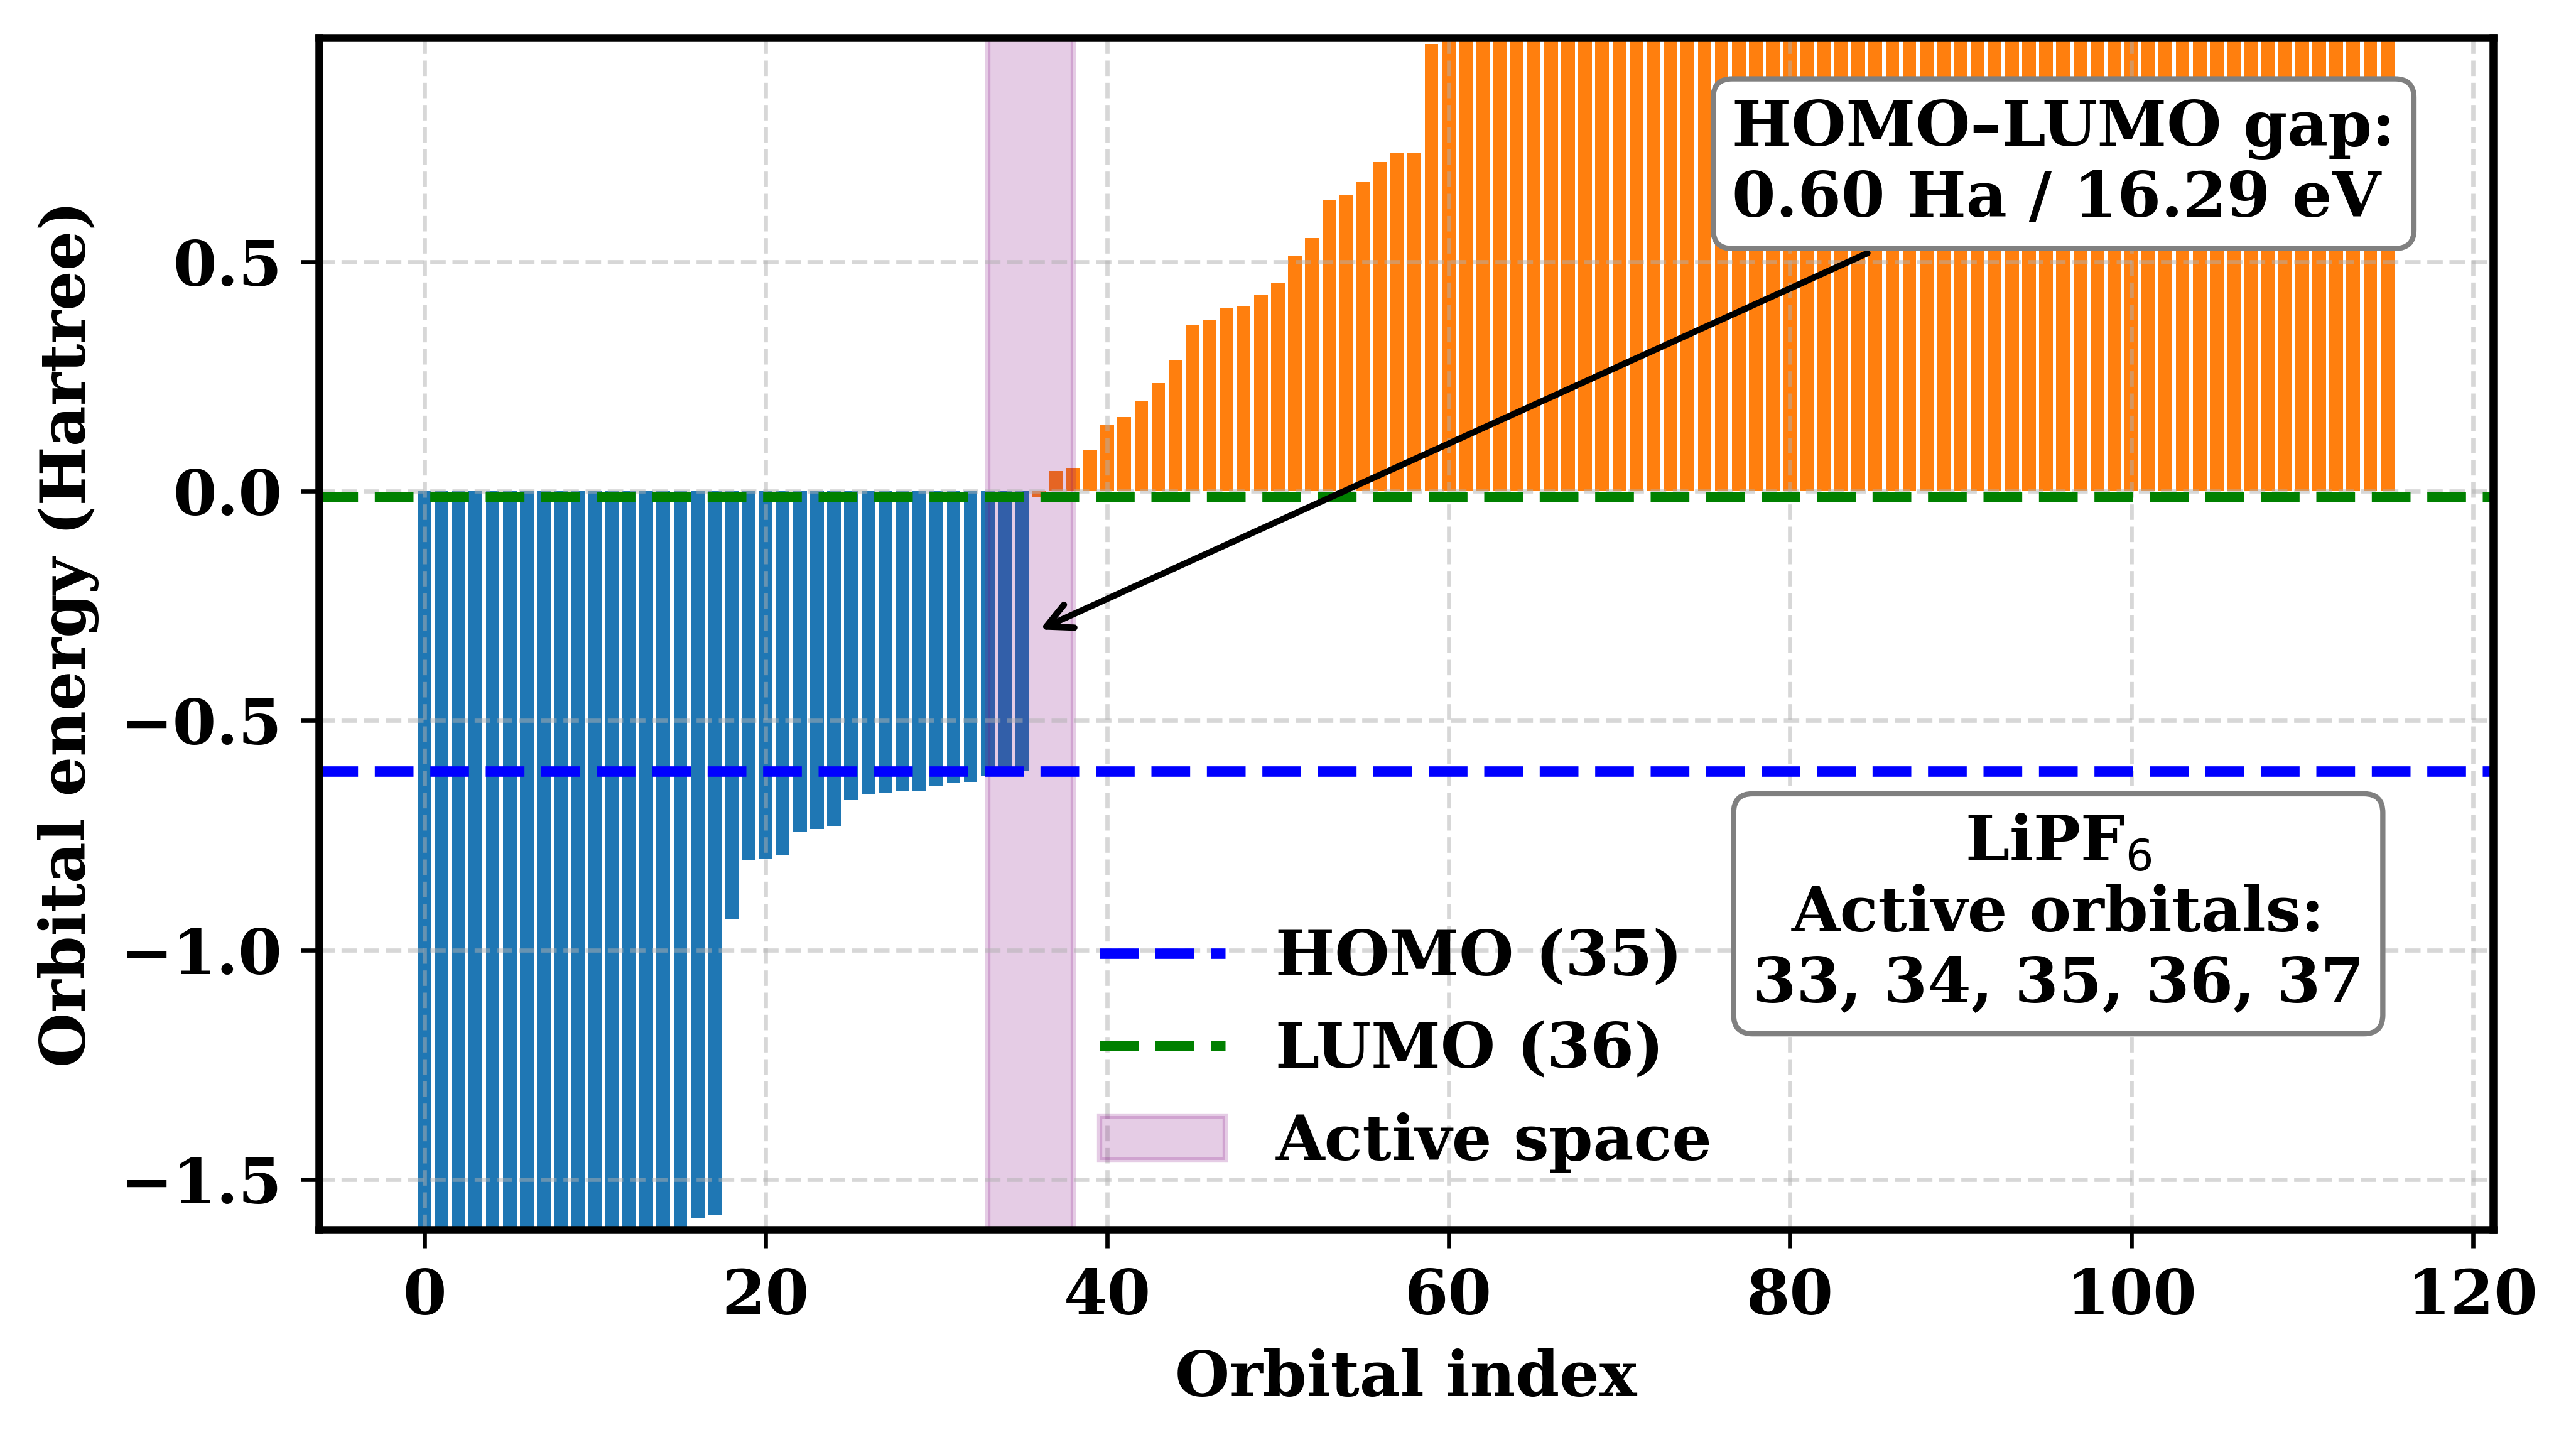

In [8]:
# Zoom window around HOMO–LUMO ± ~1 Ha
zoom_lower = homo_energy - 1.0
zoom_upper = lumo_energy + 1.0

plt.figure(figsize=(7,4))

# Bars
plt.bar(range(len(mo_energies)), mo_energies, color=colors)

# HOMO / LUMO reference lines WITH indices
plt.axhline(homo_energy, color='blue', linestyle='--', linewidth=2.0,
            label=f'HOMO ({homo})')
plt.axhline(lumo_energy, color='green', linestyle='--', linewidth=2.0,
            label=f'LUMO ({lumo})')


# ---- Annotate HOMO–LUMO gap ----
gap_ha = lumo_energy - homo_energy
gap_ev = gap_ha * 27.2114  # Hartree → eV

plt.annotate(
    f"HOMO–LUMO gap:\n{gap_ha:.2f} Ha / {gap_ev:.2f} eV",
    xy=((homo + lumo) / 2, (homo_energy + lumo_energy) / 2),
    xytext=(0.65, 0.85),
    textcoords='axes fraction',
    arrowprops=dict(arrowstyle="->", linewidth=1.2),
    fontsize=12,
    fontweight='bold',
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray")
)


# Active space shading
plt.axvspan(active_start, active_end, color='purple', alpha=0.2,
            label='Active space')

# Axis limits
plt.ylim(zoom_lower, zoom_upper)

# Axis labels
plt.xlabel("Orbital index", fontweight='bold')
plt.ylabel("Orbital energy (Hartree)", fontweight='bold')

# Title
#plt.title("(b) Zoomed view around active space", fontweight='bold')

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# ---- Explicit annotation of active orbital indices ----
active_orbital_text = ", ".join(map(str, active_orbitals))

plt.text(
    0.8, 0.35,
    f"LiPF$_6$\nActive orbitals:\n{active_orbital_text}",
    #f"Active orbitals:\n{active_orbital_text}",
    transform=plt.gca().transAxes,
    ha='center', va='top',
    fontsize=12, fontweight='bold',
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray")
)

# Legend
plt.legend(frameon=False, fontsize=11, prop=FontProperties(weight='bold'))

# === Axis Border Thickness ===
ax = plt.gca()
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# === Axis Tick Styling ===
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')


plt.tight_layout()
plt.savefig("LiPF6_orbital_energy_active_space_new.jpg", format='jpg',
            dpi=600, bbox_inches='tight')
plt.show()



Running VQE dissociation curve for basis: sto3g
  Na–F = 1.50 Å : E = -932.256696 Ha
  Na–F = 1.76 Å : E = -932.405154 Ha
  Na–F = 2.03 Å : E = -932.481620 Ha
  Na–F = 2.29 Å : E = -932.499763 Ha
  Na–F = 2.56 Å : E = -932.481264 Ha
  Na–F = 2.82 Å : E = -932.443734 Ha
  Na–F = 3.09 Å : E = -932.398371 Ha
  Na–F = 3.35 Å : E = -932.351880 Ha
  Na–F = 3.62 Å : E = -932.308384 Ha
  Na–F = 3.88 Å : E = -932.270295 Ha
  Na–F = 4.15 Å : E = -932.238659 Ha
  Na–F = 4.41 Å : E = -932.213400 Ha
  Na–F = 4.68 Å : E = -932.193726 Ha
  Na–F = 4.94 Å : E = -932.178536 Ha
  Na–F = 5.21 Å : E = -932.166748 Ha
  Na–F = 5.47 Å : E = -932.157466 Ha
  Na–F = 5.74 Å : E = -932.150020 Ha
  Na–F = 6.00 Å : E = -932.143920 Ha

Running VQE dissociation curve for basis: 631g*
  Na–F = 1.50 Å : E = -944.729056 Ha
  Na–F = 1.76 Å : E = -944.903985 Ha
  Na–F = 2.03 Å : E = -945.004344 Ha
  Na–F = 2.29 Å : E = -945.043098 Ha
  Na–F = 2.56 Å : E = -945.045606 Ha
  Na–F = 2.82 Å : E = -945.032348 Ha
  Na–F = 3.09 

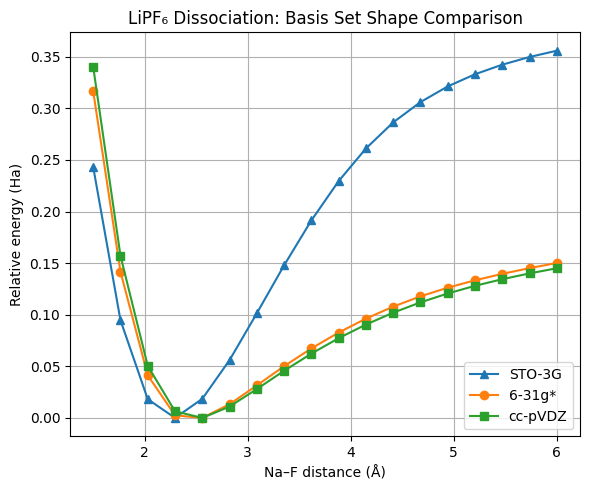

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# --- Settings ---
distances_sto3g = np.linspace(1.5, 6.0, 18)
distances_631g = np.linspace(1.5, 6.0, 18)
distances_ccpvdz = np.linspace(1.5, 6.0, 18)  # reduced grid for cc-pVDZ
basis_sets = {'sto3g': distances_sto3g, '631g*': distances_631g, 'cc-pVDZ': distances_ccpvdz}
energies_basis = {}

def vqe_energy_basis(geom: str, basis: str, n_active_elec=2, n_active_orb=2, active_indices=[4,5], maxiter=6000):
    driver = PySCFDriver(atom=geom, basis=basis, unit=DistanceUnit.ANGSTROM)
    problem = driver.run()
    remove_orbs = list(range(40, problem.num_spatial_orbitals))
    fc = FreezeCoreTransformer(freeze_core=False, remove_orbitals=list(range(0,31)) + remove_orbs)
    problem_red = fc.transform(problem)
    ast = ActiveSpaceTransformer(num_electrons=n_active_elec, num_spatial_orbitals=n_active_orb, active_orbitals=active_indices)
    problem_act = ast.transform(problem_red)
    mapper = JordanWignerMapper()
    init_state = HartreeFock(n_active_orb, problem_act.num_particles, mapper)
    ansatz = UCCSD(n_active_orb, problem_act.num_particles, mapper, initial_state=init_state)
    vqe = VQE(Estimator(), ansatz=ansatz, optimizer=COBYLA(maxiter=maxiter), initial_point=[0.0] * ansatz.num_parameters)
    solver = GroundStateEigensolver(mapper, vqe)
    res = solver.solve(problem_act)
    return res.total_energies[0].real

for basis, dists in basis_sets.items():
    print(f"\nRunning VQE dissociation curve for basis: {basis}")
    energies = []
    for d in dists:
        geom = (
            f"P 0.0000 0.0000 0.2077; "
            f"F 0.0000 1.1597 -1.1141; "
            f"F 0.0000 -1.1874 1.2692; "
            f"F -1.6097 0.0000 0.0830; "
            f"F 1.6097 0.0000 0.0830; "
            f"F 0.0000 -1.1597 -1.1141; "
            f"F 0.0000 1.1874 1.2692; "
            f"Li 0.0000 0.0000 {-d:6.4f}"
        )
        e = vqe_energy_basis(geom, basis)
        energies.append(e)
        print(f"  Na–F = {d:.2f} Å : E = {e:.6f} Ha")
    energies_basis[basis] = np.array(energies)

# Normalize each curve to its minimum value for better shape comparison
energies_shifted = {}
for basis, energies in energies_basis.items():
    energies_shifted[basis] = energies - np.min(energies)

# --- Plot normalized comparison ---
plt.figure(figsize=(6, 5))
plt.plot(distances_sto3g, energies_shifted['sto3g'], '^-', label='STO-3G')
plt.plot(distances_631g, energies_shifted['631g*'], 'o-', label='6-31g*')
plt.plot(distances_ccpvdz, energies_shifted['cc-pVDZ'], 's-', label='cc-pVDZ')

plt.xlabel('Na–F distance (Å)')
plt.ylabel('Relative energy (Ha)')
plt.title('LiPF₆ Dissociation: Basis Set Shape Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("LiPF6_dissociation_basis_shape_aligned.png", dpi=300)
plt.show()


Li–F = 1.50 Å | HF = -944.740594 | FCI = -944.740594 | VQE = -944.740594
Li–F = 1.76 Å | HF = -944.923780 | FCI = -944.923781 | VQE = -944.923781
Li–F = 2.03 Å | HF = -945.030364 | FCI = -945.030364 | VQE = -945.030364
Li–F = 2.29 Å | HF = -945.074379 | FCI = -945.079446 | VQE = -945.074379
Li–F = 2.56 Å | HF = -945.080796 | FCI = -945.096048 | VQE = -945.080797
Li–F = 2.82 Å | HF = -945.069785 | FCI = -945.095123 | VQE = -945.069786
Li–F = 3.09 Å | HF = -945.052838 | FCI = -945.088077 | VQE = -945.052839
Li–F = 3.35 Å | HF = -945.035114 | FCI = -945.079903 | VQE = -945.035114
Li–F = 3.62 Å | HF = -945.018500 | FCI = -945.072313 | VQE = -945.018501
Li–F = 3.88 Å | HF = -945.003545 | FCI = -945.065747 | VQE = -945.003545
Li–F = 4.15 Å | HF = -944.990347 | FCI = -945.060256 | VQE = -944.990347
Li–F = 4.41 Å | HF = -944.978824 | FCI = -945.055754 | VQE = -944.978824
Li–F = 4.68 Å | HF = -944.968833 | FCI = -945.052115 | VQE = -944.968834
Li–F = 4.94 Å | HF = -944.960217 | FCI = -945.04921

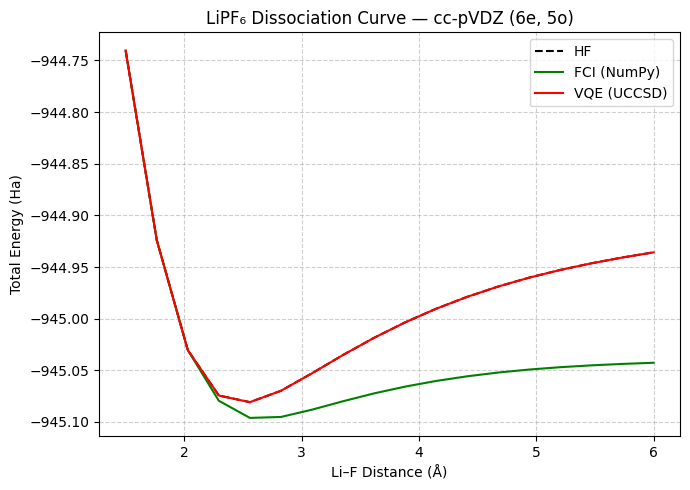

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# === Settings ===
basis = 'cc-pVDZ'
distances = np.linspace(1.5, 6.0, 18)

# === Storage ===
energies_hf = []
energies_fci = []
energies_vqe = []

# === Loop over distances ===
for d in distances:
    geom = (
        f"P 0.0000 0.0000 0.2077; "
        f"F 0.0000 1.1597 -1.1141; "
        f"F 0.0000 -1.1874 1.2692; "
        f"F -1.6097 0.0000 0.0830; "
        f"F 1.6097 0.0000 0.0830; "
        f"F 0.0000 -1.1597 -1.1141; "
        f"F 0.0000 1.1874 1.2692; "
        f"Li 0.0000 0.0000 {-d:6.4f}"
        )

    # --- Build Qiskit Nature problem ---
    driver = PySCFDriver(atom=geom, basis=basis, unit=DistanceUnit.ANGSTROM)
    problem = driver.run()

    # --- Freeze/Remove orbitals ---
    remove_orbs = list(range(40, problem.num_spatial_orbitals))
    fc = FreezeCoreTransformer(freeze_core=False, remove_orbitals=list(range(0, 31)) + remove_orbs)
    problem_red = fc.transform(problem)

    # --- Active space: 2 electrons in 2 orbitals (indices 4 and 5) ---
    ast = ActiveSpaceTransformer(num_electrons=6, num_spatial_orbitals=5, active_orbitals=[2, 3, 4, 5, 6])
    problem_act = ast.transform(problem_red)

    mapper = JordanWignerMapper()

    # --- HF ---
    energies_hf.append(problem_act.reference_energy)

    # --- FCI (NumPy exact eigensolver) ---
    fci_solver = GroundStateEigensolver(mapper, NumPyMinimumEigensolver())
    fci_result = fci_solver.solve(problem_act)
    energies_fci.append(fci_result.total_energies[0].real)

    # --- VQE with UCCSD ansatz ---
    init_state = HartreeFock(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper)
    ansatz = UCCSD(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper, initial_state=init_state)
    #ansatz = EfficientSU2(num_qubits=problem_act.num_spin_orbitals, reps=2)
    #ansatz = TwoLocal(num_qubits=problem_act.num_spin_orbitals,
                                     #rotation_blocks='ry', entanglement_blocks='cz',
                                     #reps=2, entanglement='full')

    vqe = VQE(Estimator(), ansatz=ansatz, optimizer=COBYLA(maxiter=6000), initial_point=[0.0] * ansatz.num_parameters)
    solver = GroundStateEigensolver(mapper, vqe)
    vqe_result = solver.solve(problem_act)
    energies_vqe.append(vqe_result.total_energies[0].real)

    # --- Report ---
    print(f"Li–F = {d:.2f} Å | HF = {energies_hf[-1]:.6f} | FCI = {energies_fci[-1]:.6f} | VQE = {energies_vqe[-1]:.6f}")

# === Plot: Absolute Energies ===
plt.figure(figsize=(7, 5))
plt.plot(distances, energies_hf, 'k--', label='HF')
plt.plot(distances, energies_fci, 'g-', label='FCI (NumPy)')
plt.plot(distances, energies_vqe, 'r-', label='VQE (UCCSD)')

plt.xlabel('Li–F Distance (Å)')
plt.ylabel('Total Energy (Ha)')
plt.title('LiPF₆ Dissociation Curve — cc-pVDZ (6e, 5o)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.savefig("NaPF6_ccpvdz_dissociation_HF_VQE_FCI.png", dpi=600)
plt.show()

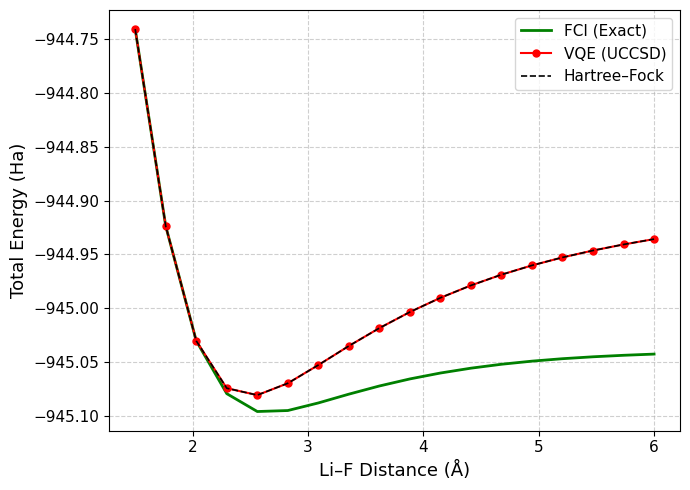

In [5]:
# === Plot: Publication-Quality Dissociation Curve ===
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 5))

# Plot lines
plt.plot(distances, energies_fci, 'g-', label='FCI (Exact)', linewidth=2.0)
plt.plot(distances, energies_vqe, 'ro-', label='VQE (UCCSD)', markersize=5, linewidth=1.5)
plt.plot(distances, energies_hf, 'k--', label='Hartree–Fock', linewidth=1.2)

# Axes
plt.xlabel('Li–F Distance (Å)', fontsize=13)
plt.ylabel('Total Energy (Ha)', fontsize=13)
#plt.title('NaPF₆ Dissociation Curve (cc-pVDZ, 2e in 2o)', fontsize=14)

# Grid, legend, layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()

# Save high-res image
plt.savefig("LiPF6_dissociation_VQE_vs_FCI_UCCSD.jpg", dpi=600)
plt.show()

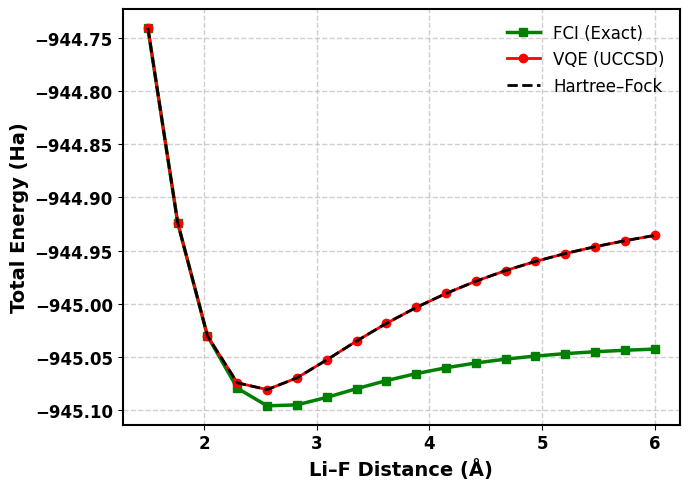

In [6]:
import matplotlib.pyplot as plt

# === Create Figure ===
plt.figure(figsize=(7, 5))

# === Plot Lines with Enhanced Style ===
plt.plot(distances, energies_fci, color='green', linestyle='-', label='FCI (Exact)', linewidth=2.5, marker='s', markersize=6)
plt.plot(distances, energies_vqe, color='red', linestyle='-', marker='o', label='VQE (UCCSD)', linewidth=2, markersize=6)
plt.plot(distances, energies_hf, color='black', linestyle='--', label='Hartree–Fock', linewidth=2)

# === Axis Labels (Bold + Readable Font) ===
plt.xlabel('Li–F Distance (Å)', fontsize=14, fontweight='bold')
plt.ylabel('Total Energy (Ha)', fontsize=14, fontweight='bold')

# === Axis Tick Styling ===
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# === Grid and Legend ===
plt.grid(True, linestyle='--', linewidth=1, alpha=0.6)
plt.legend(fontsize=12, frameon=False)

# === Axis Border Thickness ===
ax = plt.gca()
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# === Final Layout and Save ===
plt.tight_layout()
plt.savefig("LiPF6_dissociation_VQE_vs_FCI_UCCSD.jpg", dpi=600, bbox_inches='tight')  # .tiff recommended for print
plt.show()


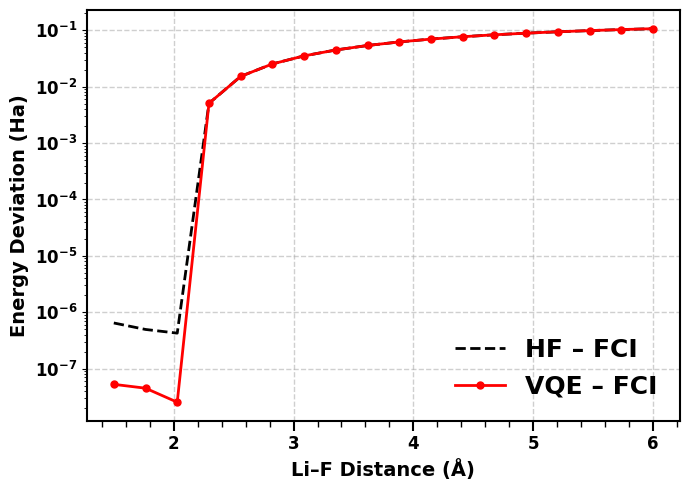

In [7]:
# === Compute Energy Deviations from FCI ===
from matplotlib.font_manager import FontProperties
import matplotlib.ticker as ticker

errors_hf = [abs(e_hf - e_fci) for e_hf, e_fci in zip(energies_hf, energies_fci)]
errors_vqe = [abs(e_vqe - e_fci) for e_vqe, e_fci in zip(energies_vqe, energies_fci)]

# === Plot: Energy Deviation from FCI ===
plt.figure(figsize=(7, 5))

plt.plot(distances, errors_hf, 'k--', label='HF – FCI', linewidth=2)
plt.plot(distances, errors_vqe, 'r-o', label='VQE – FCI', linewidth=2, markersize=5)

plt.xlabel('Li–F Distance (Å)', fontsize=14, fontweight='bold')
plt.ylabel('Energy Deviation (Ha)', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# Log scale for better error visibility
plt.yscale('log')
plt.grid(True, linestyle='--', linewidth=1, alpha=0.6)
plt.legend(prop=FontProperties(weight='bold', size=18), frameon=False,)

#  Minor ticks on x-axis
ax = plt.gca()
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(axis='x', which='minor', length=4, width=1)
ax.tick_params(axis='x', which='major', length=7, width=1.5)

# === Axis Border Thickness ===
ax = plt.gca()
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

#plt.title('Deviation from FCI — LiPF₆ cc-pVDZ (6e, 5o)', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save high-resolution image if needed
plt.savefig("LiPF6_energy_deviation_FCI.jpg", dpi=600, bbox_inches='tight')

plt.show()

/tmp/ipykernel_1685764/324388836.py:69: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  vqe = VQE(Estimator(), ansatz=ansatz, optimizer=COBYLA(maxiter=6000), initial_point=[0.0] * ansatz.num_parameters)


converged SCF energy = -944.740593700386
CASCI E = -944.740594346671  E(CI) = -9.43434199910314  S^2 = 0.0000000
Li–F = 1.50 Å | HF = -944.740594 | FCI = -944.740594 | VQE = -944.740594 | CASCI = -944.740594
converged SCF energy = -944.923780264353
CASCI E = -944.923780760393  E(CI) = -9.28248548550391  S^2 = 0.0000000
Li–F = 1.76 Å | HF = -944.923780 | FCI = -944.923781 | VQE = -944.923781 | CASCI = -944.923781
converged SCF energy = -945.030364067537
CASCI E = -945.030364494020  E(CI) = -9.08434168860958  S^2 = 0.0000000
Li–F = 2.03 Å | HF = -945.030364 | FCI = -945.030364 | VQE = -945.030364 | CASCI = -945.030364
converged SCF energy = -945.074378848625
CASCI E = -945.074379275692  E(CI) = -8.82838131705364  S^2 = 0.0000000
Li–F = 2.29 Å | HF = -945.074379 | FCI = -945.079446 | VQE = -945.074379 | CASCI = -945.074379
converged SCF energy = -945.080796079861
CASCI E = -945.080796584297  E(CI) = -8.50394835267332  S^2 = 0.0000000
Li–F = 2.56 Å | HF = -945.080796 | FCI = -945.096048 | 

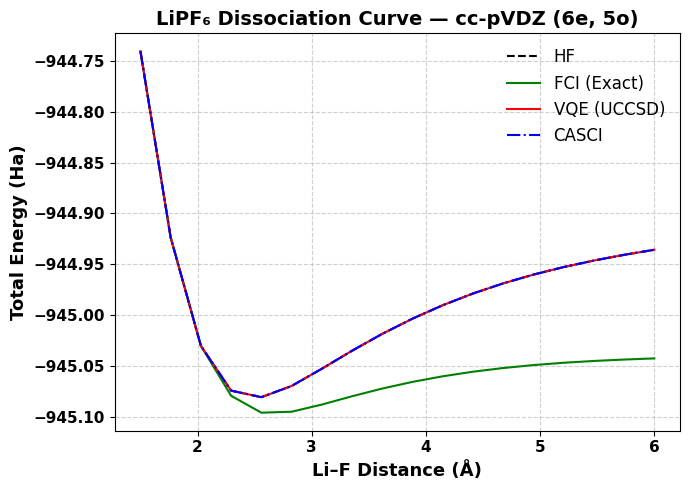

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_algorithms import VQE, NumPyMinimumEigensolver
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# === Additional imports for CASCI ===
import pyscf 
from pyscf import gto, scf, mcscf
from pyscf.lib import logger

# === Settings ===
basis = 'cc-pVDZ'
distances = np.linspace(1.5, 6.0, 18)

# === Storage ===
energies_hf = []
energies_fci = []
energies_vqe = []
energies_casci = []

# === Loop over distances ===
for d in distances:
    # --- Geometry for Qiskit and PySCF ---
    geom_str = (
        f"P 0.0000 0.0000 0.2077; "
        f"F 0.0000 1.1597 -1.1141; "
        f"F 0.0000 -1.1874 1.2692; "
        f"F -1.6097 0.0000 0.0830; "
        f"F 1.6097 0.0000 0.0830; "
        f"F 0.0000 -1.1597 -1.1141; "
        f"F 0.0000 1.1874 1.2692; "
        f"Li 0.0000 0.0000 {-d:6.4f}"
    )

    # --- Qiskit Driver ---
    driver = PySCFDriver(atom=geom_str, basis=basis, unit=DistanceUnit.ANGSTROM)
    problem = driver.run()

    # --- Freeze and reduce orbitals ---
    remove_orbs = list(range(40, problem.num_spatial_orbitals))
    fc = FreezeCoreTransformer(freeze_core=False, remove_orbitals=list(range(0, 31)) + remove_orbs)
    problem_red = fc.transform(problem)

    # --- Active space: 6 electrons in 5 orbitals ---
    ast = ActiveSpaceTransformer(num_electrons=6, num_spatial_orbitals=5, active_orbitals=[2, 3, 4, 5, 6])
    problem_act = ast.transform(problem_red)

    mapper = JordanWignerMapper()

    # --- HF ---
    energies_hf.append(problem_act.reference_energy)

    # --- FCI (exact) ---
    fci_solver = GroundStateEigensolver(mapper, NumPyMinimumEigensolver())
    fci_result = fci_solver.solve(problem_act)
    energies_fci.append(fci_result.total_energies[0].real)

    # --- VQE ---
    init_state = HartreeFock(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper)
    ansatz = UCCSD(problem_act.num_spatial_orbitals, problem_act.num_particles, mapper, initial_state=init_state)
    vqe = VQE(Estimator(), ansatz=ansatz, optimizer=COBYLA(maxiter=6000), initial_point=[0.0] * ansatz.num_parameters)
    solver = GroundStateEigensolver(mapper, vqe)
    vqe_result = solver.solve(problem_act)
    energies_vqe.append(vqe_result.total_energies[0].real)

    # === CASCI Energy ===
    mol = pyscf.gto.Mole()
    mol.atom = geom_str
    mol.basis = basis
    mol.spin = 0
    mol.charge = 0
    mol.unit = 'Angstrom'
    mol.build()

    mf = pyscf.scf.RHF(mol).run()
    mo_occ = mf.mo_occ
    homo_idx = int(np.max(np.where(mo_occ > 0)))
    lumo_idx = homo_idx + 1

    active_orbs = list(range(max(homo_idx - 2, 0), min(homo_idx + 3, mf.mo_coeff.shape[1])))
    n_active_elec = int(np.sum(mo_occ[active_orbs]))
    nelec = ((n_active_elec + mol.spin) // 2, (n_active_elec - mol.spin) // 2)

    cas = mcscf.CASCI(mf, len(active_orbs), nelec)
    mo = cas.sort_mo(active_orbs)
    cas.kernel()
    energies_casci.append(cas.e_tot)

    # --- Report ---
    print(f"Li–F = {d:.2f} Å | HF = {energies_hf[-1]:.6f} | FCI = {energies_fci[-1]:.6f} | VQE = {energies_vqe[-1]:.6f} | CASCI = {energies_casci[-1]:.6f}")

# === Plot: Absolute Energies ===
plt.figure(figsize=(7, 5))
plt.plot(distances, energies_hf, 'k--', label='HF')
plt.plot(distances, energies_fci, 'g-', label='FCI (Exact)')
plt.plot(distances, energies_vqe, 'r-', label='VQE (UCCSD)')
plt.plot(distances, energies_casci, 'b-.', label='CASCI')

plt.xlabel('Li–F Distance (Å)', fontsize=13, fontweight='bold')
plt.ylabel('Total Energy (Ha)', fontsize=13, fontweight='bold')
plt.title('LiPF₆ Dissociation Curve — cc-pVDZ (6e, 5o)', fontsize=14, fontweight='bold')
plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12, frameon=False)
plt.tight_layout()

# Save plot if needed
# plt.savefig("LiPF6_dissociation_HF_VQE_FCI_CASCI.png", dpi=600)
plt.show()


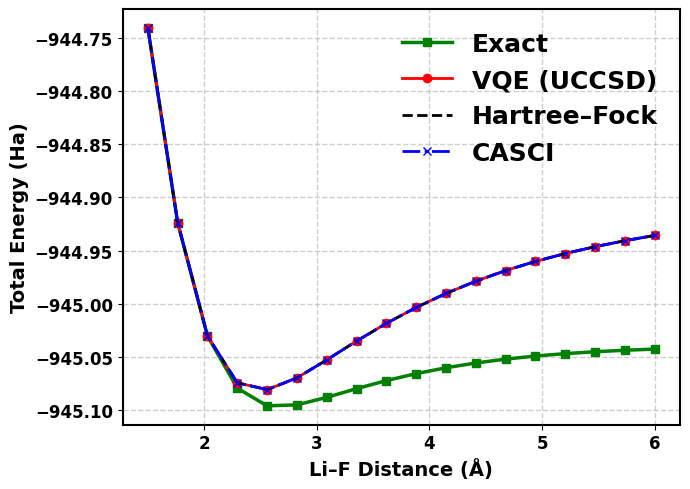

In [3]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# === Create Figure ===
plt.figure(figsize=(7, 5))

# === Plot Lines with Enhanced Style ===
plt.plot(distances, energies_fci, color='green', linestyle='-', label='Exact', linewidth=2.5, marker='s', markersize=6)
plt.plot(distances, energies_vqe, color='red', linestyle='-', marker='o', label='VQE (UCCSD)', linewidth=2, markersize=6)
plt.plot(distances, energies_hf, color='black', linestyle='--', label='Hartree–Fock', linewidth=2)
plt.plot(distances, energies_casci, color='blue', linestyle='-.', label='CASCI', linewidth=2, marker='x', markersize=6)

# === Axis Labels (Bold + Readable Font) ===
plt.xlabel('Li–F Distance (Å)', fontsize=14, fontweight='bold')
plt.ylabel('Total Energy (Ha)', fontsize=14, fontweight='bold')

# === Axis Tick Styling ===
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# === Grid and Legend ===
plt.grid(True, linestyle='--', linewidth=1, alpha=0.6)
plt.legend(prop=FontProperties(weight='bold', size=18), frameon=False)

# === Axis Border Thickness ===
ax = plt.gca()
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# === Final Layout and Save ===
plt.tight_layout()
plt.savefig("LiPF6_dissociation_VQE_vs_FCI_UCCSD.jpg", dpi=600, bbox_inches='tight')  # .tiff recommended for print
plt.show()


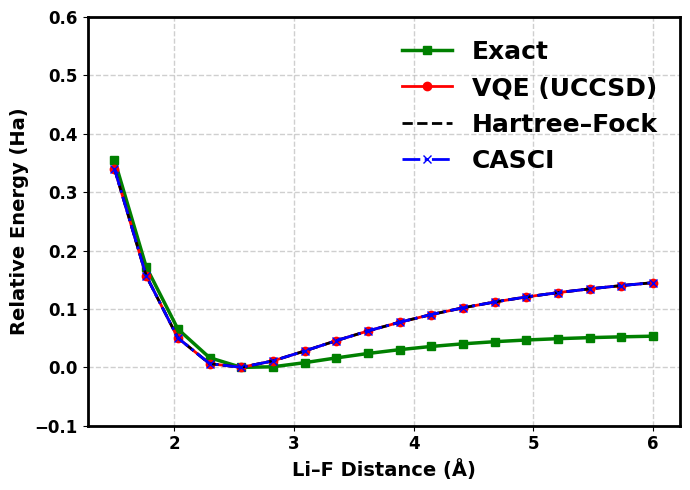

In [7]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import numpy as np

# === Convert to relative energies (key fix) ===
rel_fci   = energies_fci   - np.min(energies_fci)
rel_vqe   = energies_vqe   - np.min(energies_vqe)
rel_hf    = energies_hf    - np.min(energies_hf)
rel_casci = energies_casci - np.min(energies_casci)

# === Create Figure ===
plt.figure(figsize=(7, 5))

# === Plot relative dissociation curves ===
plt.plot(distances, rel_fci,
         color='green', linestyle='-', linewidth=2.5,
         marker='s', markersize=6, label='Exact')

plt.plot(distances, rel_vqe,
         color='red', linestyle='-', linewidth=2,
         marker='o', markersize=6, label='VQE (UCCSD)')

plt.plot(distances, rel_hf,
         color='black', linestyle='--', linewidth=2,
         label='Hartree–Fock')

plt.plot(distances, rel_casci,
         color='blue', linestyle='-.', linewidth=2,
         marker='x', markersize=6, label='CASCI')

# === Axis Labels ===
plt.xlabel('Li–F Distance (Å)', fontsize=14, fontweight='bold')
plt.ylabel('Relative Energy (Ha)', fontsize=14, fontweight='bold')

# === FIXED energy scale (consistent across all panels) ===
plt.ylim(-0.1, 0.6)

# === Axis Tick Styling ===
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# === Grid and Legend ===
plt.grid(True, linestyle='--', linewidth=1, alpha=0.6)
plt.legend(prop=FontProperties(weight='bold', size=18), frameon=False)

# === Axis Border Thickness ===
ax = plt.gca()
ax.spines['top'].set_linewidth(2.0)
ax.spines['right'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.spines['bottom'].set_linewidth(2.0)

# === IMPORTANT FIX: disable scientific offset ===
ax.ticklabel_format(axis='y', style='plain', useOffset=False)

# === Final Layout and Save ===
plt.tight_layout()
plt.savefig("LiPF6_dissociation_relative_energy.jpg",
            dpi=600, bbox_inches='tight')
plt.show()

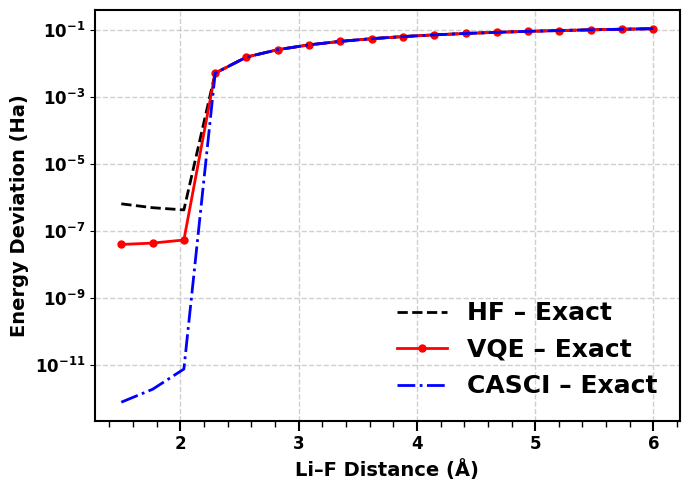

In [12]:
# === Compute Energy Deviations from FCI ===
from matplotlib.font_manager import FontProperties
import matplotlib.ticker as ticker

errors_hf = [abs(e_hf - e_fci) for e_hf, e_fci in zip(energies_hf, energies_fci)]
errors_vqe = [abs(e_vqe - e_fci) for e_vqe, e_fci in zip(energies_vqe, energies_fci)]
errors_casci = [abs(e_casci - e_fci) for e_casci, e_fci in zip(energies_casci, energies_fci)]

# === Plot: Energy Deviation from FCI ===
plt.figure(figsize=(7, 5))

plt.plot(distances, errors_hf, 'k--', label='HF – Exact', linewidth=2)
plt.plot(distances, errors_vqe, 'r-o', label='VQE – Exact', linewidth=2, markersize=5)
plt.plot(distances, errors_casci, 'b-.', label='CASCI – Exact', linewidth=2, markersize=5)

plt.xlabel('Li–F Distance (Å)', fontsize=14, fontweight='bold')
plt.ylabel('Energy Deviation (Ha)', fontsize=14, fontweight='bold')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# Log scale for better error visibility
plt.yscale('log')
plt.grid(True, linestyle='--', linewidth=1, alpha=0.6)
plt.legend(prop=FontProperties(weight='bold', size=18), frameon=False,)

#  Minor ticks on x-axis
ax = plt.gca()
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(axis='x', which='minor', length=4, width=1)
ax.tick_params(axis='x', which='major', length=7, width=1.5)

# === Axis Border Thickness ===
ax = plt.gca()
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

#plt.title('Deviation from FCI — LiPF₆ cc-pVDZ (6e, 5o)', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save high-resolution image if needed
plt.savefig("LiPF6_energy_deviation_FCI.jpg", dpi=600, bbox_inches='tight')

plt.show()

In [1]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.transformers import FreezeCoreTransformer, ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver, QEOM, EvaluationRule
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import Estimator

# ──────────────────────────────────────────────────────────────────────────────
# 1.  Geometry
# ──────────────────────────────────────────────────────────────────────────────
lipf6_geometry = (
    "P 0.0000 0.0000 0.2077; "
    "F 0.0000 1.1597 -1.1141; "
    "F 0.0000 -1.1874 1.2692; "
    "F -1.6097 0.0000 0.0830; "
    "F 1.6097 0.0000 0.0830; "
    "F 0.0000 -1.1597 -1.1141; "
    "F 0.0000 1.1874 1.2692; "
    "Li 0.0000 0.0000 -2.4673"
)

driver = PySCFDriver(atom=lipf6_geometry,
                     basis='cc-pVDZ',
                     charge=0,
                     spin=0,
                     unit=DistanceUnit.ANGSTROM)
problem = driver.run()

print("── Original HF problem ─────────────────────────")
print("Spatial orbitals :", problem.num_spatial_orbitals)
print("Spin  orbitals   :", problem.num_spin_orbitals)
na, nb = problem.num_particles
print(f"Electrons        : {na+nb} ({na} α, {nb} β)\n")

# ──────────────────────────────────────────────────────────────────────────────
# 2.  Freeze‑core + trim high‑energy virtuals
# ──────────────────────────────────────────────────────────────────────────────
freeze_core     = list(range(0, 31))
remove_orbitals = list(range(40, problem.num_spatial_orbitals))

fc = FreezeCoreTransformer(freeze_core=False,
                           remove_orbitals=remove_orbitals+freeze_core)
problem_red = fc.transform(problem)

all_orbs     = set(range(problem.num_spatial_orbitals))
frozen_orbs  = set(freeze_core)
removed_orbs = set(remove_orbitals)
kept_fc      = sorted(all_orbs - frozen_orbs - removed_orbs)

print("── After FreezeCoreTransformer ────────────────")
print("Frozen orbitals   :", sorted(freeze_core))
print("Removed virtuals  :", sorted(remove_orbitals))
print("Kept orbitals     :", kept_fc)
print("Spatial orbitals  :", problem_red.num_spatial_orbitals, "\n")
na, nb = problem_red.num_particles
print(f"Electrons        : {na+nb} ({na} α, {nb} β)\n")

# ──────────────────────────────────────────────────────────────────────────────
# 3.  Active‑space reduction (6 e⁻ in 5 MOs)
# ──────────────────────────────────────────────────────────────────────────────
active_orbs_reduced = [3, 4, 5]
ast = ActiveSpaceTransformer(
    num_electrons=4,
    num_spatial_orbitals=3,
    active_orbitals=active_orbs_reduced
)
problem_act = ast.transform(problem_red)

active_original = [kept_fc[i] for i in active_orbs_reduced]

print("── Active space ───────────────────────────────")
print("Active orbitals (re‑indexed) :", active_orbs_reduced)
print("Active orbitals (original HF):", active_original)
print("Spatial orbitals              :", problem_act.num_spatial_orbitals)
na, nb = problem_act.num_particles
print(f"Electrons                     : {na+nb} ({na} α, {nb} β)\n")

# ──────────────────────────────────────────────────────────────────────────────
# 4.  Qubit mapping, ansatz, VQE + QEOM for excited states
# ──────────────────────────────────────────────────────────────────────────────
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(problem_act.second_q_ops()[0])

init_state = HartreeFock(problem_act.num_spatial_orbitals,
                         problem_act.num_particles, mapper)
ansatz = UCCSD(problem_act.num_spatial_orbitals,
               problem_act.num_particles, mapper,
               initial_state=init_state)

vqe = VQE(estimator=Estimator(),
          ansatz=ansatz,
          optimizer=COBYLA(maxiter=10000))
vqe.initial_point = [0.0] * ansatz.num_parameters

gs_solver = GroundStateEigensolver(mapper, vqe)

# --- QEOM for excited states ---
qeom_solver = QEOM(gs_solver, Estimator(), "sd", EvaluationRule.ALL)
qeom_result = qeom_solver.solve(problem_act)

print("── VQE + QEOM results ────────────────────────────────")
hartree_to_ev = 27.2114
energies = [e.real for e in qeom_result.total_energies]
ground = energies[0]
for i, e in enumerate(energies):
    label = "Ground" if i == 0 else f"Excited {i}"
    delta_e = e - ground if i > 0 else 0
    print(f"{label} state: {e:.6f} Ha", end="")
    if i > 0:
        print(f"   ΔE = {delta_e:.6f} Ha ≈ {delta_e*hartree_to_ev:.2f} eV")
    else:
        print()

── Original HF problem ─────────────────────────
Spatial orbitals : 116
Spin  orbitals   : 232
Electrons        : 72 (36 α, 36 β)

── After FreezeCoreTransformer ────────────────
Frozen orbitals   : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
Removed virtuals  : [40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115]
Kept orbitals     : [31, 32, 33, 34, 35, 36, 37, 38, 39]
Spatial orbitals  : 9 

Electrons        : 10 (5 α, 5 β)

── Active space ───────────────────────────────
Active orbitals (re‑indexed) : [3, 4, 5]
Active orbitals (original HF): [34, 35, 36]
Spatial orbitals              : 3
Electrons                     : 4 (2 α, 2 β)

── VQE + QEOM res